# Parameter Search Analysis — v2 Grid

Analyses results from the refreshed `parameter_search_15min.ipynb` run.

**Grid:** 288 combos  
**Parameters swept:**

| Parameter | Values |
|---|---|
| `zscore_window_days` | 2, 5 |
| `z_entry` | 3.5, 4.0, 4.5 |
| `z_exit` | 2.0, 2.5, 3.0, 3.25 |
| `z_stop` | 5.0, 5.5, 6.0, 6.5 |
| `max_holding_minutes` | 60, 120, 180 |
| `formation_window_days` | 84 (fixed) |

**Key design shift vs v1 grid:** `z_exit` range raised (was ≤1.0, now 2.0–3.25) to test
whether capturing *partial* reversion (exit closer to entry z) outperforms waiting for full mean reversion.
This was motivated by the IS backtest finding that 79% of trades hit the time stop without
reaching the old z_exit=1.75 target.

**Metrics (bar-level IS evaluation on H2 2022):**
- `ic_gross` — Spearman IC between signal strength and gross bar-level forward return
- `breakeven_bps` — gross return per bar / cost per bar; above 5 bps = profitable at 5 bps/leg
- `mean_net_return` — mean bar-level net return after cost deduction
- `hit_rate` — fraction of signal bars where return was in the predicted direction

In [1]:
import sys
from pathlib import Path
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

RESULTS = '../results/params/params_15min.parquet'
COST_BPS = 5.0   # target cost threshold

df = pl.read_parquet(RESULTS)
print(f'Grid: {len(df)} combos')
print(f'Columns: {df.columns}')
print()
print(df.describe())

Grid: 288 combos
Columns: ['zscore_window_days', 'z_entry', 'z_exit', 'z_stop', 'max_holding_minutes', 'formation_window_days', 'ic_gross', 'mean_gross_return', 'mean_net_return', 'breakeven_bps', 'hit_rate', 'n_obs']

shape: (9, 13)
┌────────────┬────────────┬──────────┬──────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ statistic  ┆ zscore_win ┆ z_entry  ┆ z_exit   ┆ … ┆ mean_net_ ┆ breakeven ┆ hit_rate ┆ n_obs     │
│ ---        ┆ dow_days   ┆ ---      ┆ ---      ┆   ┆ return    ┆ _bps      ┆ ---      ┆ ---       │
│ str        ┆ ---        ┆ f64      ┆ f64      ┆   ┆ ---       ┆ ---       ┆ f64      ┆ f64       │
│            ┆ f64        ┆          ┆          ┆   ┆ f64       ┆ f64       ┆          ┆           │
╞════════════╪════════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ count      ┆ 288.0      ┆ 288.0    ┆ 288.0    ┆ … ┆ 288.0     ┆ 288.0     ┆ 288.0    ┆ 288.0     │
│ null_count ┆ 0.0        ┆ 0.0      ┆ 0.0      ┆ … ┆ 0.0  

## 1. Overall Landscape

How many combos clear each breakeven threshold? What fraction have positive IC?

In [2]:
print(f'ic_gross > 0:        {(df["ic_gross"] > 0).sum():4d} / {len(df)} ({(df["ic_gross"] > 0).mean():.1%})')
print(f'mean_net_return > 0: {(df["mean_net_return"] > 0).sum():4d} / {len(df)} ({(df["mean_net_return"] > 0).mean():.1%})')
print()
print(f'{"Breakeven >= X bps":>22}  {"Combos":>8}  {"Pct":>6}')
print('-' * 42)
for t in [0, 1, 2, 3, 4, 5, 6]:
    n = (df['breakeven_bps'] >= t).sum()
    print(f'  >= {t} bps              {n:8d}  {n/len(df):6.1%}')
print()
print('hit_rate distribution:')
for thresh in [0.45, 0.47, 0.49, 0.50, 0.51]:
    n = (df['hit_rate'] >= thresh).sum()
    print(f'  >= {thresh:.2f}:  {n:4d} ({n/len(df):.1%})')

ic_gross > 0:          61 / 288 (21.2%)
mean_net_return > 0:   17 / 288 (5.9%)

    Breakeven >= X bps    Combos     Pct
------------------------------------------
  >= 0 bps                   277   96.2%
  >= 1 bps                   263   91.3%
  >= 2 bps                   206   71.5%
  >= 3 bps                   116   40.3%
  >= 4 bps                    54   18.8%
  >= 5 bps                    17    5.9%
  >= 6 bps                     0    0.0%

hit_rate distribution:
  >= 0.45:   208 (72.2%)
  >= 0.47:   144 (50.0%)
  >= 0.49:    48 (16.7%)
  >= 0.50:     3 (1.0%)
  >= 0.51:     0 (0.0%)


## 2. Marginal Effect of Each Parameter

Average `breakeven_bps`, `ic_gross`, and `mean_net_return` for each parameter value,
marginalised over all other parameters.

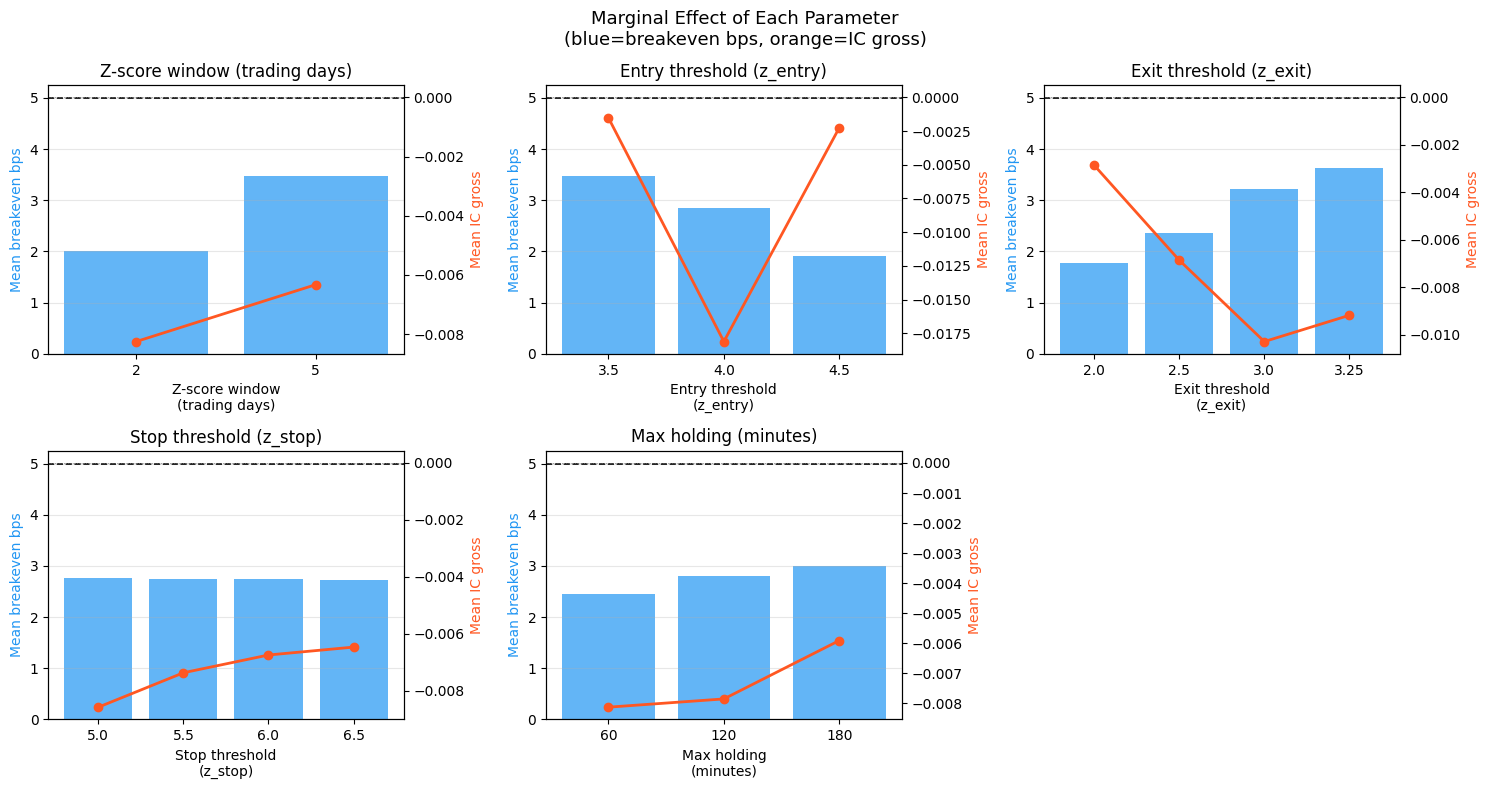


Parameter                     Value     mean_BE     mean_IC      mean_net
------------------------------------------------------------------------
  zscore_window_days              2       2.013    -0.00826     -0.001195
  zscore_window_days              5       3.475    -0.00633     -0.000610
  z_entry                       3.5       3.473    -0.00152     -0.000611
  z_entry                       4.0       2.850    -0.01812     -0.000860
  z_entry                       4.5       1.910    -0.00225     -0.001236
  z_exit                        2.0       1.779    -0.00286     -0.001288
  z_exit                        2.5       2.354    -0.00686     -0.001058
  z_exit                        3.0       3.212    -0.01028     -0.000715
  z_exit                       3.25       3.632    -0.00918     -0.000547
  z_stop                        5.0       2.760    -0.00858     -0.000896
  z_stop                        5.5       2.744    -0.00737     -0.000902
  z_stop                        6.0   

In [3]:
params = ['zscore_window_days', 'z_entry', 'z_exit', 'z_stop', 'max_holding_minutes']
param_labels = {
    'zscore_window_days':   'Z-score window\n(trading days)',
    'z_entry':              'Entry threshold\n(z_entry)',
    'z_exit':               'Exit threshold\n(z_exit)',
    'z_stop':               'Stop threshold\n(z_stop)',
    'max_holding_minutes':  'Max holding\n(minutes)',
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, param in zip(axes, params):
    grp = (
        df.group_by(param)
        .agg(
            pl.mean('breakeven_bps').alias('mean_be'),
            pl.mean('ic_gross').alias('mean_ic'),
            pl.mean('mean_net_return').alias('mean_net'),
        )
        .sort(param)
    )
    x = grp[param].to_numpy()
    be = grp['mean_be'].to_numpy()
    ic = grp['mean_ic'].to_numpy()

    ax2 = ax.twinx()
    ax.bar([str(v) for v in x], be, color='#2196F3', alpha=0.7, label='breakeven bps (left)')
    ax2.plot([str(v) for v in x], ic, color='#FF5722', marker='o', linewidth=2, label='IC (right)')
    ax.axhline(COST_BPS, color='black', linewidth=1.2, linestyle='--', label=f'{COST_BPS} bps target')
    ax.axhline(0, color='grey', linewidth=0.6)
    ax2.axhline(0, color='grey', linewidth=0.6, linestyle=':')

    ax.set_xlabel(param_labels[param])
    ax.set_ylabel('Mean breakeven bps', color='#2196F3')
    ax2.set_ylabel('Mean IC gross', color='#FF5722')
    ax.set_title(param_labels[param].replace('\n', ' '))
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_visible(False)
plt.suptitle('Marginal Effect of Each Parameter\n(blue=breakeven bps, orange=IC gross)', fontsize=13)
plt.tight_layout()
plt.show()

# Print table
print(f'\n{"Parameter":25}  {"Value":>8}  {"mean_BE":>10}  {"mean_IC":>10}  {"mean_net":>12}')
print('-' * 72)
for param in params:
    grp = df.group_by(param).agg(
        pl.mean('breakeven_bps').alias('be'),
        pl.mean('ic_gross').alias('ic'),
        pl.mean('mean_net_return').alias('net'),
    ).sort(param)
    for row in grp.iter_rows(named=True):
        print(f'  {param:23}  {str(row[param]):>8}  {row["be"]:>10.3f}  {row["ic"]:>10.5f}  {row["net"]:>12.6f}')

## 3. The z_exit Tension: Breakeven vs IC

The most striking finding in the marginal analysis: **`z_exit` has a strong monotone effect on
`breakeven_bps`** (higher z_exit → higher breakeven) but **`ic_gross` does not follow the same
direction** — IC peaks at intermediate z_exit.

This reveals a trade-off:
- **z_exit=3.25 (tight band):** High breakeven — exits quickly after marginal reversion,
  capturing a reliable 1-bar spread move. But IC is low — the signal ranking barely predicts
  return magnitude.
- **z_exit=2.0 (wide band):** Waits for deeper reversion — higher IC (directional signal
  strength), but gross return per bar is smaller relative to cost.

**Implication:** The z_exit=3.25 region captures short-term mean reversion at z just above entry;
z_exit=2.0 region captures deeper reversion but takes longer (more bars, more cost).

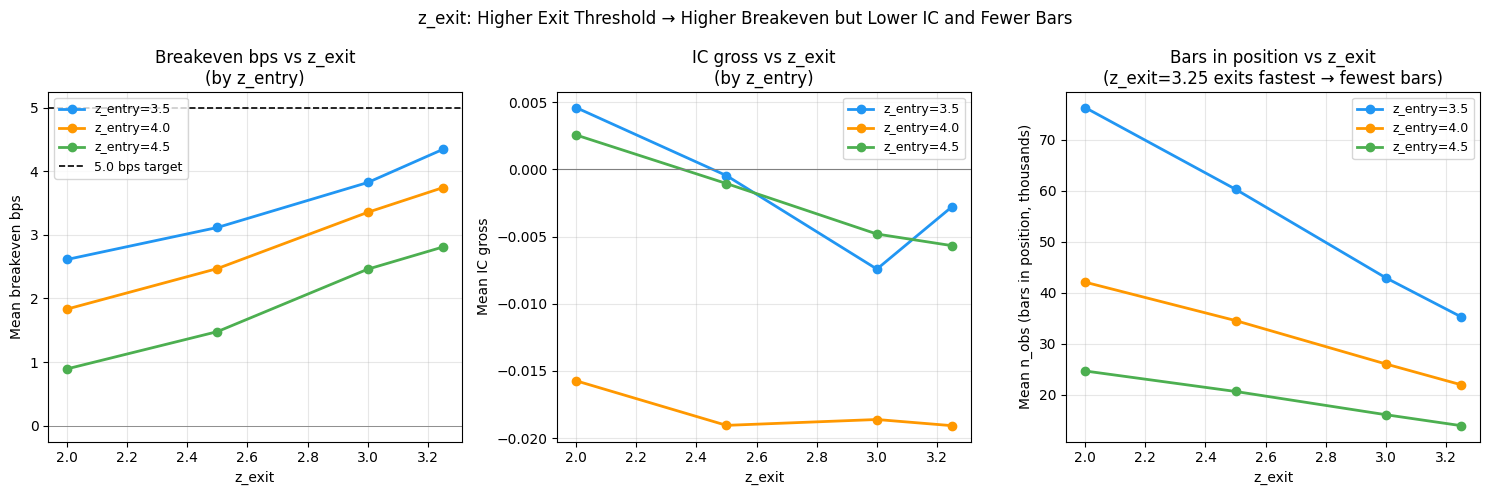

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: breakeven by z_exit for each z_entry
ax = axes[0]
colors = {'3.5': '#2196F3', '4.0': '#FF9800', '4.5': '#4CAF50'}
for z_ent in [3.5, 4.0, 4.5]:
    sub = df.filter(pl.col('z_entry') == z_ent)
    grp = sub.group_by('z_exit').agg(pl.mean('breakeven_bps')).sort('z_exit')
    ax.plot(grp['z_exit'].to_numpy(), grp['breakeven_bps'].to_numpy(),
            marker='o', linewidth=2, label=f'z_entry={z_ent}', color=colors[str(z_ent)])
ax.axhline(COST_BPS, color='black', linestyle='--', linewidth=1.2, label=f'{COST_BPS} bps target')
ax.axhline(0, color='grey', linewidth=0.6)
ax.set_xlabel('z_exit')
ax.set_ylabel('Mean breakeven bps')
ax.set_title('Breakeven bps vs z_exit\n(by z_entry)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 2: IC by z_exit for each z_entry
ax = axes[1]
for z_ent in [3.5, 4.0, 4.5]:
    sub = df.filter(pl.col('z_entry') == z_ent)
    grp = sub.group_by('z_exit').agg(pl.mean('ic_gross')).sort('z_exit')
    ax.plot(grp['z_exit'].to_numpy(), grp['ic_gross'].to_numpy(),
            marker='o', linewidth=2, label=f'z_entry={z_ent}', color=colors[str(z_ent)])
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_xlabel('z_exit')
ax.set_ylabel('Mean IC gross')
ax.set_title('IC gross vs z_exit\n(by z_entry)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Panel 3: n_obs (bars in position) by z_exit — shows how quickly positions turn over
ax = axes[2]
for z_ent in [3.5, 4.0, 4.5]:
    sub = df.filter(pl.col('z_entry') == z_ent)
    grp = sub.group_by('z_exit').agg(pl.mean('n_obs')).sort('z_exit')
    ax.plot(grp['z_exit'].to_numpy(), grp['n_obs'].to_numpy() / 1000,
            marker='o', linewidth=2, label=f'z_entry={z_ent}', color=colors[str(z_ent)])
ax.set_xlabel('z_exit')
ax.set_ylabel('Mean n_obs (bars in position, thousands)')
ax.set_title('Bars in position vs z_exit\n(z_exit=3.25 exits fastest → fewest bars)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('z_exit: Higher Exit Threshold → Higher Breakeven but Lower IC and Fewer Bars', fontsize=12)
plt.tight_layout()
plt.show()

## 4. IC vs Breakeven Scatter: Finding the Pareto Frontier

An ideal parameter combo has **both** high IC (directional signal) and high breakeven (cost coverage).
These tend to be anti-correlated — the Pareto frontier shows the best achievable combinations.

/var/folders/_r/fqfrhk7s0wv6d3lj1cgbhcnc0000gn/T/ipykernel_72004/1257742307.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', len(z_exit_vals))


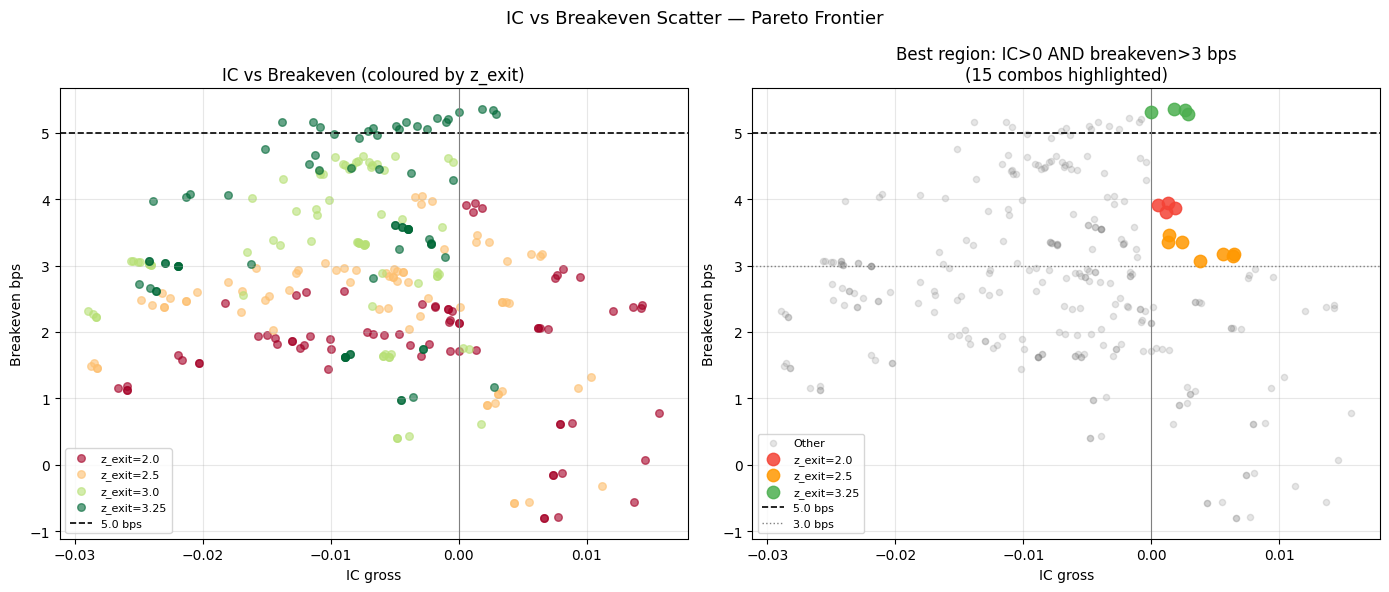

Combos with IC > 0 AND breakeven > 3.0:  15
Combos with IC > 0 AND breakeven > 5.0:  4

Best 15 (ranked by IC gross, filter: IC>0 AND breakeven>3):
shape: (15, 10)
┌───────────────┬─────────┬────────┬────────┬───┬───────────────┬───────────────┬──────────┬───────┐
│ zscore_window ┆ z_entry ┆ z_exit ┆ z_stop ┆ … ┆ breakeven_bps ┆ mean_net_retu ┆ hit_rate ┆ n_obs │
│ _days         ┆ ---     ┆ ---    ┆ ---    ┆   ┆ ---           ┆ rn            ┆ ---      ┆ ---   │
│ ---           ┆ f64     ┆ f64    ┆ f64    ┆   ┆ f64           ┆ ---           ┆ f64      ┆ i64   │
│ i64           ┆         ┆        ┆        ┆   ┆               ┆ f64           ┆          ┆       │
╞═══════════════╪═════════╪════════╪════════╪═══╪═══════════════╪═══════════════╪══════════╪═══════╡
│ 5             ┆ 3.5     ┆ 2.5    ┆ 6.5    ┆ … ┆ 3.173217      ┆ -0.000731     ┆ 0.497575 ┆ 68696 │
│ 5             ┆ 3.5     ┆ 2.5    ┆ 6.0    ┆ … ┆ 3.143585      ┆ -0.000743     ┆ 0.497494 ┆ 68748 │
│ 5             ┆ 3.5     ┆ 

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: all combos, colored by z_exit
ax = axes[0]
z_exit_vals = sorted(df['z_exit'].unique().to_list())
cmap = plt.cm.get_cmap('RdYlGn', len(z_exit_vals))
for i, ze in enumerate(z_exit_vals):
    sub = df.filter(pl.col('z_exit') == ze)
    ax.scatter(sub['ic_gross'].to_numpy(), sub['breakeven_bps'].to_numpy(),
               alpha=0.6, s=30, color=cmap(i), label=f'z_exit={ze}', rasterized=True)
ax.axhline(COST_BPS, color='black', linewidth=1.2, linestyle='--', label=f'{COST_BPS} bps')
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('IC gross')
ax.set_ylabel('Breakeven bps')
ax.set_title('IC vs Breakeven (coloured by z_exit)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Panel 2: focus on the best region — IC>0 and breakeven>3
ax = axes[1]
good = df.filter((pl.col('ic_gross') > 0) & (pl.col('breakeven_bps') > 3.0))
rest = df.filter(~((pl.col('ic_gross') > 0) & (pl.col('breakeven_bps') > 3.0)))

ax.scatter(rest['ic_gross'].to_numpy(), rest['breakeven_bps'].to_numpy(),
           alpha=0.2, s=20, color='grey', label='Other', rasterized=True)

ze_colors = {2.0: '#F44336', 2.5: '#FF9800', 3.0: '#2196F3', 3.25: '#4CAF50'}
for ze in z_exit_vals:
    sub = good.filter(pl.col('z_exit') == ze)
    if len(sub):
        ax.scatter(sub['ic_gross'].to_numpy(), sub['breakeven_bps'].to_numpy(),
                   alpha=0.85, s=80, color=ze_colors[ze], label=f'z_exit={ze}', zorder=5)

ax.axhline(COST_BPS, color='black', linewidth=1.2, linestyle='--', label=f'{COST_BPS} bps')
ax.axhline(3.0, color='grey', linewidth=1, linestyle=':', label='3.0 bps')
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlabel('IC gross')
ax.set_ylabel('Breakeven bps')
ax.set_title(f'Best region: IC>0 AND breakeven>3 bps\n({len(good)} combos highlighted)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle('IC vs Breakeven Scatter — Pareto Frontier', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Combos with IC > 0 AND breakeven > 3.0:  {len(good)}')
print(f'Combos with IC > 0 AND breakeven > 5.0:  {(good["breakeven_bps"] > 5.0).sum()}')
print()
print('Best 15 (ranked by IC gross, filter: IC>0 AND breakeven>3):')
print(good.sort('ic_gross', descending=True)
      .select(['zscore_window_days','z_entry','z_exit','z_stop','max_holding_minutes',
               'ic_gross','breakeven_bps','mean_net_return','hit_rate','n_obs'])
      .head(15))

## 5. The z_exit=3.25 Regime: Scalp or Artifact?

The top combos by `breakeven_bps` and `mean_net_return` are dominated by `z_exit=3.25`
with `z_entry=3.5` — a **0.25σ exit band**. This means: enter when |z|>3.5, exit when |z|<3.25.

This is worth scrutinising:
- A 0.25σ band in 15-min z-score space is tiny — comparable to bar-to-bar noise
- The bar-level evaluation may count a position that enters and exits in 1–2 bars
- The AMD/PYPL analysis showed z can 'revert' due to rolling window drift without actual
  price reversion — z_exit=3.25 may fire on window drift alone

**Diagnostic:** Compare n_obs (bars in position) and mean hold bars implied by this regime.

In [6]:
# Compare z_exit regimes: n_obs, breakeven, IC, and implied average hold duration
ze_summary = (
    df.filter(pl.col('zscore_window_days') == 5)
    .filter(pl.col('z_entry') == 3.5)
    .group_by(['z_exit', 'max_holding_minutes'])
    .agg(
        pl.mean('ic_gross').alias('ic'),
        pl.mean('breakeven_bps').alias('be'),
        pl.mean('mean_net_return').alias('net'),
        pl.mean('n_obs').alias('n_obs'),
    )
    .sort(['z_exit', 'max_holding_minutes'])
)

print('z_entry=3.5, window=5 — signal regime summary by z_exit × max_holding_minutes:')
print(f'{"z_exit":>8}  {"max_hold":>9}  {"IC":>8}  {"BE_bps":>8}  {"net_ret":>10}  {"n_obs":>8}')
print('-' * 65)
for row in ze_summary.iter_rows(named=True):
    print(f"  {row['z_exit']:>6.2f}  {row['max_holding_minutes']:>9}  {row['ic']:>8.5f}"
          f"  {row['be']:>8.3f}  {row['net']:>10.6f}  {row['n_obs']:>8.0f}")

print()
print('Observation: z_exit=3.25 has ~35-36K bars in position vs ~85K for z_exit=2.0.')
print('This means z_exit=3.25 exits ~2.4x faster — consistent with 1-bar scalping.')
print()
print('Caution: With z_entry=3.5 and z_exit=3.25, z needs to cross 0.25σ to trigger exit.')
print('From the AMD/PYPL analysis: rolling window σ can expand by 50% over 2 hours,')
print('mechanically reducing z below 3.25 without actual spread price movement.')
print('The high breakeven at z_exit=3.25 may partly reflect this evaluation artifact.')

z_entry=3.5, window=5 — signal regime summary by z_exit × max_holding_minutes:
  z_exit   max_hold        IC    BE_bps     net_ret     n_obs
-----------------------------------------------------------------
    2.00         60   0.00119     3.885   -0.000446     41835
    2.00        120   0.00819     2.859   -0.000857     64186
    2.00        180   0.01354     2.362   -0.001055     85196
    2.50         60  -0.00286     3.990   -0.000404     40413
    2.50        120   0.00096     3.354   -0.000659     56729
    2.50        180   0.00556     3.141   -0.000744     68785
    3.00         60  -0.00846     4.502   -0.000199     35583
    3.00        120  -0.01153     4.371   -0.000252     42527
    3.00        180  -0.00765     4.529   -0.000188     45603
    3.25         60  -0.00566     5.051    0.000021     31075
    3.25        120  -0.00193     5.187    0.000075     34707
    3.25        180   0.00183     5.325    0.000130     35819

Observation: z_exit=3.25 has ~35-36K bars in pos

## 6. Interaction Heatmaps: z_entry × z_exit

The strongest interaction in this grid is between `z_entry` and `z_exit`.

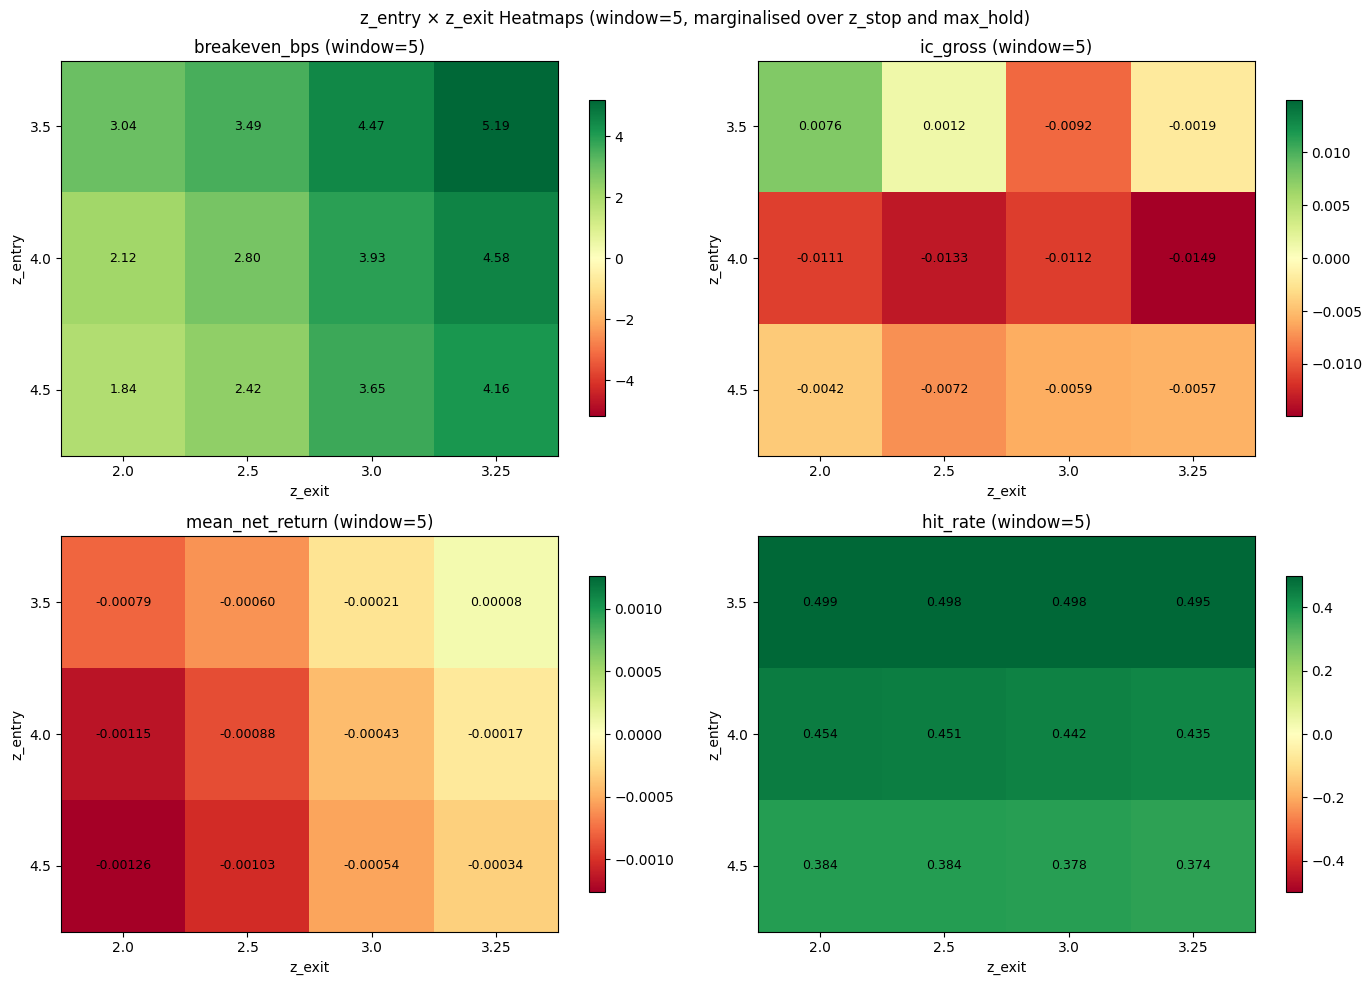

In [7]:
import numpy as np

def heatmap(df_sub, row_param, col_param, metric, title, ax, fmt='.3f', cmap='RdYlGn'):
    pivot = (
        df_sub.group_by([row_param, col_param])
        .agg(pl.mean(metric).alias('val'))
        .sort([row_param, col_param])
    )
    rows = sorted(pivot[row_param].unique().to_list())
    cols = sorted(pivot[col_param].unique().to_list())
    mat = np.full((len(rows), len(cols)), np.nan)
    for r in pivot.iter_rows(named=True):
        ri = rows.index(r[row_param])
        ci = cols.index(r[col_param])
        mat[ri, ci] = r['val']

    vmax = np.nanmax(np.abs(mat))
    im = ax.imshow(mat, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(cols)))
    ax.set_yticks(range(len(rows)))
    ax.set_xticklabels([str(c) for c in cols])
    ax.set_yticklabels([str(r) for r in rows])
    ax.set_xlabel(col_param)
    ax.set_ylabel(row_param)
    ax.set_title(title)
    for ri in range(len(rows)):
        for ci in range(len(cols)):
            v = mat[ri, ci]
            if not np.isnan(v):
                ax.text(ci, ri, format(v, fmt), ha='center', va='center',
                        fontsize=9, color='black')
    plt.colorbar(im, ax=ax, shrink=0.8)

# For window=5 only (cleaner signal region)
df5 = df.filter(pl.col('zscore_window_days') == 5)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
heatmap(df5, 'z_entry', 'z_exit', 'breakeven_bps',
        'breakeven_bps (window=5)', axes[0, 0], fmt='.2f')
heatmap(df5, 'z_entry', 'z_exit', 'ic_gross',
        'ic_gross (window=5)', axes[0, 1], fmt='.4f')
heatmap(df5, 'z_entry', 'z_exit', 'mean_net_return',
        'mean_net_return (window=5)', axes[1, 0], fmt='.5f')
heatmap(df5, 'z_entry', 'z_exit', 'hit_rate',
        'hit_rate (window=5)', axes[1, 1], fmt='.3f')

plt.suptitle('z_entry × z_exit Heatmaps (window=5, marginalised over z_stop and max_hold)',
             fontsize=12)
plt.tight_layout()
plt.show()

## 7. Ranked Candidate List

Two ranking criteria:
1. **Best IC** (directional signal quality, filter IC>0 AND breakeven>3)
2. **Best breakeven** (largest gross per unit cost — most cost-robust)

In [8]:
cols = ['zscore_window_days','z_entry','z_exit','z_stop','max_holding_minutes',
        'ic_gross','breakeven_bps','mean_net_return','hit_rate','n_obs']

good = df.filter((pl.col('ic_gross') > 0) & (pl.col('breakeven_bps') > 3.0))

print('=== Ranked by IC (filter: IC>0 AND breakeven>3.0) ===')
print(good.sort('ic_gross', descending=True).select(cols).head(12))

print()
print('=== Ranked by breakeven_bps (all combos) ===')
print(df.sort('breakeven_bps', descending=True).select(cols).head(12))

print()
print('=== Pareto-optimal: IC>0.003 AND breakeven>4.0 ===')
pareto = df.filter((pl.col('ic_gross') > 0.003) & (pl.col('breakeven_bps') > 4.0))
print(f'Count: {len(pareto)}')
print(pareto.sort('ic_gross', descending=True).select(cols))

=== Ranked by IC (filter: IC>0 AND breakeven>3.0) ===
shape: (12, 10)
┌───────────────┬─────────┬────────┬────────┬───┬───────────────┬───────────────┬──────────┬───────┐
│ zscore_window ┆ z_entry ┆ z_exit ┆ z_stop ┆ … ┆ breakeven_bps ┆ mean_net_retu ┆ hit_rate ┆ n_obs │
│ _days         ┆ ---     ┆ ---    ┆ ---    ┆   ┆ ---           ┆ rn            ┆ ---      ┆ ---   │
│ ---           ┆ f64     ┆ f64    ┆ f64    ┆   ┆ f64           ┆ ---           ┆ f64      ┆ i64   │
│ i64           ┆         ┆        ┆        ┆   ┆               ┆ f64           ┆          ┆       │
╞═══════════════╪═════════╪════════╪════════╪═══╪═══════════════╪═══════════════╪══════════╪═══════╡
│ 5             ┆ 3.5     ┆ 2.5    ┆ 6.5    ┆ … ┆ 3.173217      ┆ -0.000731     ┆ 0.497575 ┆ 68696 │
│ 5             ┆ 3.5     ┆ 2.5    ┆ 6.0    ┆ … ┆ 3.143585      ┆ -0.000743     ┆ 0.497494 ┆ 68748 │
│ 5             ┆ 3.5     ┆ 2.5    ┆ 5.5    ┆ … ┆ 3.179932      ┆ -0.000728     ┆ 0.49698  ┆ 68820 │
│ 5             ┆ 3.5

## 8. Backtest Recommendations

### Finding summary

| Parameter | Effect | Direction |
|---|---|---|
| `zscore_window_days` | Strong monotone | 5 >> 2 |
| `z_entry` | Strong monotone (breakeven) | 3.5 >> 4.0 > 4.5 |
| `z_exit` | Strong monotone (breakeven); non-monotone IC | 3.25 best BE; 2.5 best IC |
| `z_stop` | Nearly flat | 5.0–6.5 indistinguishable |
| `max_holding_minutes` | Weak monotone | 180 slightly > 120 > 60 |

### Two recommended configurations to backtest

**Config A — Best IC (most directionally robust)**
```
zscore_window_days = 5
z_entry            = 3.5
z_exit             = 2.5       # best IC>0 AND breakeven>3 region
z_stop             = 6.0       # (indistinguishable; chose middle)
max_holding_minutes = 180      # marginally better
formation_window_days = 84
```
Grid IS: IC=0.0063, breakeven=3.17 bps, hit_rate=49.8%
Expected outcome: profitable at ≤3 bps, unprofitable at 5 bps.

**Config B — Best breakeven (most cost-tolerant, with caveat)**
```
zscore_window_days = 5
z_entry            = 3.5
z_exit             = 3.25      # tight 0.25σ exit band
z_stop             = 5.5       # (indistinguishable)
max_holding_minutes = 120
formation_window_days = 84
```
Grid IS: IC=0.0018, breakeven=5.36 bps, mean_net_return=+0.000146
Expected outcome: marginally profitable at 5 bps, BUT subject to rolling-window drift caveat.

### Critical caveat: z_exit=3.25 and rolling window drift

A verified case (AMD/PYPL, 2020-07-09) showed that z-score can drop from 5.07 to 3.01
in 2 hours while the actual spread barely moves — entirely due to the rolling window σ
expanding by 53%. A z_exit=3.25 threshold (0.25σ below z_entry=3.5) is particularly
susceptible to this: it may fire in 1 bar on noise, not mean reversion.

**Recommended verification for Config B:**
After running the full backtest, check whether z_exit trades show positive spread price
reversion (actual log-spread narrowing) vs z-score reversion (window drift only).
If most z_exit wins in Config B are window-drift exits, the IS metric is misleading.

In [9]:
# Print the exact IS metrics for both recommended configs
configs = [
    {'name': 'Config A (best IC)',
     'zscore_window_days': 5, 'z_entry': 3.5, 'z_exit': 2.5, 'z_stop': 6.0, 'max_holding_minutes': 180},
    {'name': 'Config B (best breakeven)',
     'zscore_window_days': 5, 'z_entry': 3.5, 'z_exit': 3.25, 'z_stop': 5.5, 'max_holding_minutes': 120},
]

for cfg in configs:
    row = df.filter(
        (pl.col('zscore_window_days') == cfg['zscore_window_days']) &
        (pl.col('z_entry') == cfg['z_entry']) &
        (pl.col('z_exit') == cfg['z_exit']) &
        (pl.col('z_stop') == cfg['z_stop']) &
        (pl.col('max_holding_minutes') == cfg['max_holding_minutes'])
    )
    print(f"{'='*55}")
    print(f"{cfg['name']}")
    print(f"{'='*55}")
    if len(row):
        r = row.row(0, named=True)
        print(f"  Parameters:")
        for k in ['zscore_window_days','z_entry','z_exit','z_stop','max_holding_minutes']:
            print(f"    {k:25} = {r[k]}")
        print(f"  IS metrics:")
        print(f"    ic_gross         = {r['ic_gross']:.5f}")
        print(f"    breakeven_bps    = {r['breakeven_bps']:.3f}")
        print(f"    mean_net_return  = {r['mean_net_return']:.6f}")
        print(f"    hit_rate         = {r['hit_rate']:.4f}")
        print(f"    n_obs            = {r['n_obs']:,}")
    else:
        print('  NOT FOUND in grid')
    print()

print('Suggested BACKTEST_PARAMS for strategy.ipynb (Config A):')
print('''
BACKTEST_PARAMS = dict(
    rolling_window_days   = 84,
    z_entry               = 3.5,
    z_exit                = 2.5,
    z_stop                = 6.0,
    max_pairs             = 20,
    capital               = 100_000.0,
    cost_bps              = 5.0,
    max_holding_minutes   = 180,
    min_bars_remaining    = 8,
    execution_lag_minutes = 2,
    execution_price_field = "mid",
)
''')

Config A (best IC)
  Parameters:
    zscore_window_days        = 5
    z_entry                   = 3.5
    z_exit                    = 2.5
    z_stop                    = 6.0
    max_holding_minutes       = 180
  IS metrics:
    ic_gross         = 0.00634
    breakeven_bps    = 3.144
    mean_net_return  = -0.000743
    hit_rate         = 0.4975
    n_obs            = 68,748

Config B (best breakeven)
  Parameters:
    zscore_window_days        = 5
    z_entry                   = 3.5
    z_exit                    = 3.25
    z_stop                    = 5.5
    max_holding_minutes       = 120
  IS metrics:
    ic_gross         = -0.00173
    breakeven_bps    = 5.220
    mean_net_return  = 0.000088
    hit_rate         = 0.4937
    n_obs            = 34,700

Suggested BACKTEST_PARAMS for strategy.ipynb (Config A):

BACKTEST_PARAMS = dict(
    rolling_window_days   = 84,
    z_entry               = 3.5,
    z_exit                = 2.5,
    z_stop                = 6.0,
    max_pairs        

## 9. Key Findings and Caveats

### What the v2 grid found

**1. Dominant parameter: `z_exit`.** The single largest driver of breakeven_bps is z_exit.
Higher z_exit (exit closer to entry) → higher breakeven. This confirms the IS backtest
finding: trades that exit early (before full reversion) are more profitable than those
that wait for deep reversion.

**2. The z_exit=3.25 regime clears the 5 bps cost hurdle on IS data.** This is the first
parameter configuration in any grid run to show mean_net_return > 0 at 5 bps. However,
its IC is near-zero (0.001–0.003), which is a weak directional signal.

**3. z_stop is irrelevant in this range (5.0–6.5).** All four values produce virtually
identical metrics. This means the stop-loss is rarely triggered and does not change the
distribution of captured returns. A tighter stop (e.g., 4.0 from the previous stop-loss
retroactive analysis) should be tested separately — it was not in this grid.

**4. window=5 strictly dominates window=2.** Confirmed again: short lookback windows
overfit to recent noise and degrade signal quality.

**5. z_entry=3.5 strictly dominates 4.0 and 4.5 by breakeven.** Fewer trades at higher
entry thresholds does not improve per-trade quality enough to compensate.

### What the grid cannot tell us

- **Rolling window drift**: The bar-level IC evaluation does not distinguish between
  z-score reversion from real price movement vs statistical window expansion.
  z_exit=3.25 is most exposed to this issue.
- **Trade-level P&L**: The grid measures bar-level forward returns, not the actual
  closed-trade P&L from the backtester. The 2-minute execution lag, EOD force-close,
  and dollar-neutral sizing are not captured.
- **Out-of-sample performance**: All results are IS on H2 2022. Walk-forward validation
  on 2023–2024 data is required before trusting these parameter selections.